# Bike Lane Quality Classification — Group Pipeline (Unsupervised Stage)

**Course:** 5ARE0 — Human Activity Recognition Assignment
**Stage:** Multi-participant merge → preprocessing → feature engineering → 4 unsupervised models

This notebook merges all 6 recordings (Himanshu, Aniket, Yuhan — each with one smooth and
one bumpy ride), builds a shared feature set, and applies four unsupervised clustering
methods to see whether smooth/bumpy structure emerges without using the labels for training.
Labels are used **only afterward**, to evaluate whether each method's discovered clusters
line up with the true classes.

> Supervised models (4 required by the assignment) are added once that part of the course
> is covered — see the "Next steps" section at the end.


## 0. Environment & Reproducibility

In [1]:
import sys, platform
import pandas as pd, numpy as np, sklearn, matplotlib
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__,
      "| scikit-learn:", sklearn.__version__, "| matplotlib:", matplotlib.__version__)


Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.2.3 | numpy: 2.3.5 | scikit-learn: 1.9.0 | matplotlib: 3.10.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option('display.max_columns', None)


## 1. Data Loading & Sensor Merge (All Participants)

Same merge logic as before: `Accelerometer`, `Gravity`, and `Gyroscope` share identical
timestamps row-for-row (confirmed per recording via the assertions below), so a direct
column-wise merge is safe without interpolation.

**Edit the `RECORDINGS` list below** to point at your local folders — one entry per
(participant, condition) recording. This is the only thing that needs to change as more
data comes in.

In [3]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """Merge Accelerometer, Gravity, and Gyroscope CSVs (same clock, same row count)
    into a single per-timestamp dataframe."""
    acc  = pd.read_csv(acc_path).rename(columns={'x': 'acc_x',  'y': 'acc_y',  'z': 'acc_z'})
    grav = pd.read_csv(grav_path).rename(columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'})
    gyro = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    assert len(acc) == len(grav) == len(gyro), "Row counts differ — use merge_asof instead"
    assert (acc['time'].values == grav['time'].values).all(), "Timestamps misaligned (accel vs gravity)"
    assert (acc['time'].values == gyro['time'].values).all(), "Timestamps misaligned (accel vs gyro)"

    df = acc[['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']].copy()
    df[['grav_x', 'grav_y', 'grav_z']] = grav[['grav_x', 'grav_y', 'grav_z']]
    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[['gyro_x', 'gyro_y', 'gyro_z']]
    return df


In [5]:
# --- EDIT THESE PATHS to point at your own exported recordings ---
RECORDINGS = [
    dict(folder='../data_raw/Smooth/Himanshu_Smooth_data', participant='Himanshu', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Himanshu_Bumpy_data', participant='Himanshu', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Smooth/Aniket_Smooth_data', participant='Aniket', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Aniket_Bumpy_data', participant='Aniket', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Smooth/Yuhan_Smooth_data', participant='Yuhan', label='smooth',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
    dict(folder='../data_raw/Bumpy/Yuhan_Bumpy_data', participant='Yuhan', label='bumpy',
         acc='Accelerometer.csv', grav='Gravity.csv', gyro='Gyroscope.csv'),
]

merged_recordings = {}
for rec in RECORDINGS:
    key = f"{rec['participant']}_{rec['label']}"
    df = load_and_merge(f"{rec['folder']}/{rec['acc']}", f"{rec['folder']}/{rec['grav']}", f"{rec['folder']}/{rec['gyro']}")
    merged_recordings[key] = df
    print(f"{key:20s} -> {len(df)} rows, {df['seconds_elapsed'].max():.1f}s")


Himanshu_smooth      -> 8540 rows, 85.5s
Himanshu_bumpy       -> 18010 rows, 180.4s
Aniket_smooth        -> 15258 rows, 153.8s
Aniket_bumpy         -> 19553 rows, 197.2s
Yuhan_smooth         -> 4763 rows, 47.8s
Yuhan_bumpy          -> 7583 rows, 76.2s


## 2. Trim — Fixed Window (Not Adaptive)

**Why not the adaptive rolling-std trim from the single-recording prototype?** It was
tested against all 6 real recordings before committing to it here, and it failed badly:
a threshold tuned on one recording didn't transfer (some participants' phones sit at a
much higher baseline vibration than others — a fixed *absolute* threshold either barely
trimmed some recordings or over-trimmed others). A *relative* (per-recording percentile)
version was tried next and was worse — on recordings without one clean, extended quiet
stretch, it silently deleted large legitimate chunks of ride data (in one case, 43+
seconds from the front of a bumpy recording).

**The fix: a small, fixed, bounded trim (1.5s each end)**, applied uniformly. Less clever,
but predictable — it can only ever remove the first/last couple of seconds (confirmed
separately to capture phone-handling motion), and can never silently eat real ride data
the way the adaptive versions did. This is a real methodological decision worth stating
explicitly in the report's "Preprocessing pipeline and rationale" section — trying an
adaptive approach, testing it against real multi-participant data, and rejecting it when
it didn't hold up is a stronger story than an untested "smarter" method.

In [6]:
def fixed_trim(df, trim_seconds=1.5):
    """Drop a small, fixed window from each end and re-zero elapsed time."""
    t_start = df['seconds_elapsed'].min() + trim_seconds
    t_end   = df['seconds_elapsed'].max() - trim_seconds
    out = df[(df['seconds_elapsed'] >= t_start) & (df['seconds_elapsed'] <= t_end)].reset_index(drop=True)
    out['seconds_elapsed'] = out['seconds_elapsed'] - out['seconds_elapsed'].iloc[0]
    return out

trimmed_recordings = {key: fixed_trim(df, trim_seconds=1.5) for key, df in merged_recordings.items()}
for key, df in trimmed_recordings.items():
    print(f"{key:20s} -> {df['seconds_elapsed'].max():.1f}s after trim")


Himanshu_smooth      -> 82.5s after trim
Himanshu_bumpy       -> 177.3s after trim
Aniket_smooth        -> 150.8s after trim
Aniket_bumpy         -> 194.1s after trim
Yuhan_smooth         -> 44.8s after trim
Yuhan_bumpy          -> 73.1s after trim


## 3. Windowing & Feature Extraction

Unchanged from the single-recording prototype: 2s windows, 50% overlap (1s stride), and
6 summary statistics (mean, std, min, max, RMS, IQR) per channel across accelerometer
x/y/z/magnitude, gyroscope x/y/z/magnitude, and gravity x/y/z (11 channels × 6 stats =
66 features per window).

Every window is tagged with its `label` (smooth/bumpy — used only for evaluation below,
never for training the clustering models), `participant`, and `recording` id.

In [7]:
WINDOW = 200   # 2s at ~100Hz
STRIDE = 100   # 1s -> 50% overlap

def make_windows(df, window=WINDOW, stride=STRIDE):
    n = len(df)
    starts = list(range(0, n - window + 1, stride))
    return [df.iloc[s:s+window] for s in starts], starts

def extract_features(win):
    feats = {}
    acc_mag  = np.sqrt(win['acc_x']**2  + win['acc_y']**2  + win['acc_z']**2)
    gyro_mag = np.sqrt(win['gyro_x']**2 + win['gyro_y']**2 + win['gyro_z']**2)
    channels = {
        'acc_x': win['acc_x'], 'acc_y': win['acc_y'], 'acc_z': win['acc_z'], 'acc_mag': acc_mag,
        'gyro_x': win['gyro_x'], 'gyro_y': win['gyro_y'], 'gyro_z': win['gyro_z'], 'gyro_mag': gyro_mag,
        'grav_x': win['grav_x'], 'grav_y': win['grav_y'], 'grav_z': win['grav_z'],
    }
    for name, series in channels.items():
        feats[f'{name}_mean'] = series.mean()
        feats[f'{name}_std']  = series.std()
        feats[f'{name}_min']  = series.min()
        feats[f'{name}_max']  = series.max()
        feats[f'{name}_rms']  = np.sqrt(np.mean(series**2))
        feats[f'{name}_iqr']  = series.quantile(0.75) - series.quantile(0.25)
    return feats

def build_dataset(df, label, participant, recording_id):
    windows, starts = make_windows(df)
    rows = []
    for win, s in zip(windows, starts):
        f = extract_features(win)
        f['label'] = label
        f['participant'] = participant
        f['recording'] = recording_id
        f['window_start_t'] = win['seconds_elapsed'].iloc[0]
        rows.append(f)
    return pd.DataFrame(rows)

all_feats = []
for rec in RECORDINGS:
    key = f"{rec['participant']}_{rec['label']}"
    feats = build_dataset(trimmed_recordings[key], label=rec['label'], participant=rec['participant'], recording_id=key)
    all_feats.append(feats)
    print(f'{key:20s} -> {len(feats)} windows')

data = pd.concat(all_feats, ignore_index=True)
print('\nTotal windows:', len(data))
print(data.groupby(['participant', 'label']).size())


Himanshu_smooth      -> 81 windows
Himanshu_bumpy       -> 176 windows
Aniket_smooth        -> 148 windows
Aniket_bumpy         -> 191 windows
Yuhan_smooth         -> 43 windows
Yuhan_bumpy          -> 71 windows

Total windows: 710
participant  label 
Aniket       bumpy     191
             smooth    148
Himanshu     bumpy     176
             smooth     81
Yuhan        bumpy      71
             smooth     43
dtype: int64


## 4. Dimensionality Reduction (PCA)

66 features is a lot for distance-based clustering — especially DBSCAN, which suffers
from the "curse of dimensionality" (in high dimensions, all points start looking roughly
equidistant, making density estimation unreliable). This directly follows the "Link
between PCA and Clustering" idea from the course: PCA is applied first to strip
low-variance noise dimensions, keeping enough components to retain 95% of the variance,
and all four clustering models are run on this same reduced representation for a fair
comparison.

`StandardScaler` is fit **before** PCA — PCA is scale-sensitive, so without this,
features with larger raw magnitude (e.g. `acc_mag_max`, range 0–50+) would dominate the
components over features with small raw magnitude (e.g. IQR near 0–2), regardless of
which is actually more informative.

Components needed for 95% variance: 17 (out of 66 original features)
PCA-reduced shape: (710, 17)


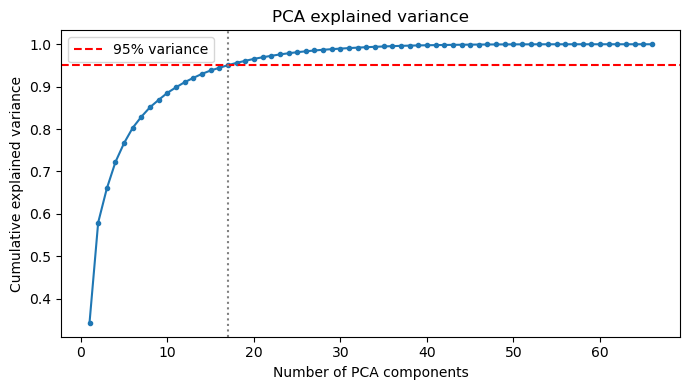

In [8]:
feature_cols = [c for c in data.columns if c not in ('label', 'participant', 'recording', 'window_start_t')]
X = data[feature_cols].values
y_true = LabelEncoder().fit_transform(data['label'])  # smooth/bumpy -> 0/1, for evaluation only

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components_95} (out of {X_scaled.shape[1]} original features)')

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
print('PCA-reduced shape:', X_pca.shape)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=3)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_components_95, color='gray', linestyle=':')
plt.xlabel('Number of PCA components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Four Unsupervised Models

**K-Means** (partitional, hard assignment) and **Agglomerative Hierarchical Clustering**
(bottom-up, Ward linkage) both assume roughly compact, globular groupings and need `k`
specified upfront (`n_clusters=2`, matching smooth/bumpy).

**DBSCAN** (density-based) needs no cluster count, but needs `eps` and `min_samples`.
`eps` is chosen via the standard k-distance graph method from the course notes: plot each
point's distance to its `min_samples`-th nearest neighbor, sorted ascending, and look for
the elbow — the point where distances start climbing sharply signals the density
threshold separating cluster interiors from sparser regions/noise.

**Gaussian Mixture Model** (probabilistic, soft assignment) fits 2 Gaussian components
and assigns each window to whichever component is most probable — the "hardened" version
of its soft output, for comparability with the other three.

c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

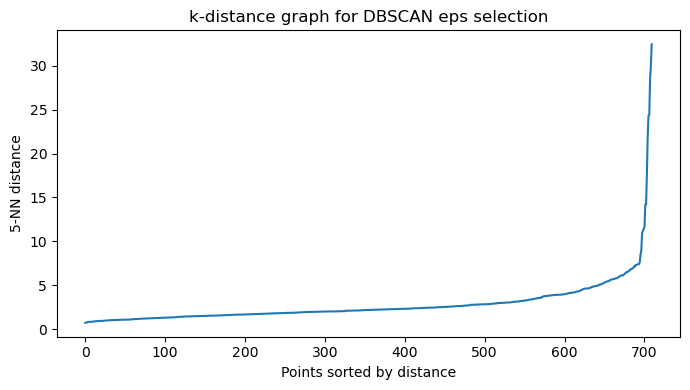

Candidate eps (90th percentile of k-dist): 4.881


In [9]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.xlabel('Points sorted by distance'); plt.ylabel(f'{min_samples}-NN distance')
plt.title('k-distance graph for DBSCAN eps selection')
plt.tight_layout()
plt.show()

# Heuristic starting point — the 90th percentile of the k-distance curve;
# confirm this lands near the visual elbow above, and adjust if not.
eps_candidate = np.percentile(k_dist, 90)
print(f'Candidate eps (90th percentile of k-dist): {eps_candidate:.3f}')


In [10]:
def purity_score(y_true, y_pred):
    """Fraction of points whose cluster's majority true-label matches their own —
    an external evaluation metric not built into sklearn."""
    df = pd.DataFrame({'true': y_true, 'pred': y_pred})
    majority_sum = df.groupby('pred')['true'].agg(lambda x: x.value_counts().max()).sum()
    return majority_sum / len(df)

results = []

km = KMeans(n_clusters=2, n_init=10, random_state=42)
results.append(('K-Means', km.fit_predict(X_pca)))

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
results.append(('Agglomerative', agg.fit_predict(X_pca)))

db = DBSCAN(eps=eps_candidate, min_samples=min_samples)
results.append(('DBSCAN', db.fit_predict(X_pca)))

gmm = GaussianMixture(n_components=2, random_state=42)
results.append(('GMM', gmm.fit_predict(X_pca)))

print(f"{'Model':15s} {'n_clusters':>10s} {'noise%':>8s} {'silhouette':>11s} {'ARI':>8s} {'purity':>8s}")
for name, labels in results:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100 if -1 in labels else 0.0
    mask = labels != -1
    sil = silhouette_score(X_pca[mask], labels[mask]) if len(set(labels[mask])) > 1 else float('nan')
    ari = adjusted_rand_score(y_true, labels)
    purity = purity_score(y_true, labels)
    print(f"{name:15s} {n_clusters:10d} {noise_pct:7.1f}% {sil:11.3f} {ari:8.3f} {purity:8.3f}")
    data[f'cluster_{name.lower().replace("-","")}'] = labels


Model           n_clusters   noise%  silhouette      ARI   purity
K-Means                  2     0.0%       0.266    0.476    0.845
Agglomerative            2     0.0%       0.231    0.585    0.883
DBSCAN                   3     7.2%       0.421    0.041    0.675
GMM                      2     0.0%       0.220    0.042    0.617


c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


## 6. Visual Comparison (PCA 2D Projection)

Projecting onto the first two principal components lets you eyeball what each model
actually did, side by side with the ground truth. Note this 2D view is a simplification
(it's only 2 of the `n_components_95` dimensions actually used for clustering), so a
model can look "wrong" here while still having used real separation in a dimension not
shown — treat this as an intuition aid, not the full picture.

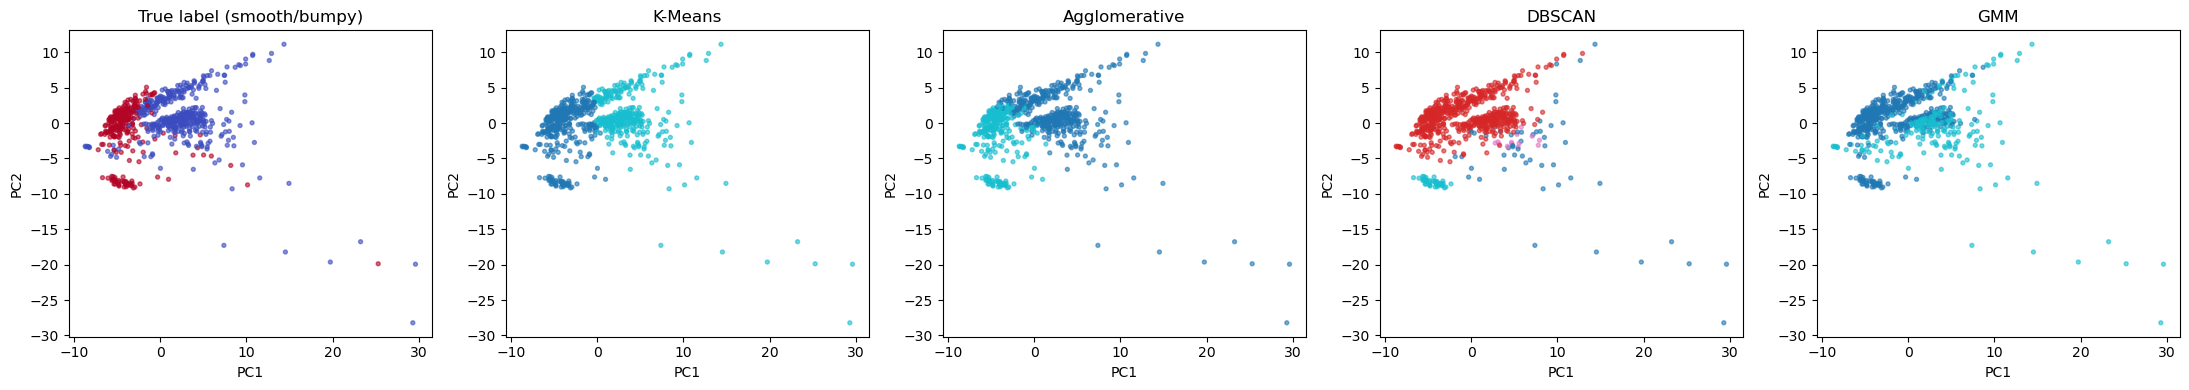

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title('True label (smooth/bumpy)')
for ax, (name, labels) in zip(axes[1:], results):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=8, alpha=0.6)
    ax.set_title(name)
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()


## 7. Diagnostic: Do the Clusters Reflect Road Quality, or Something Else?

A model can score well internally (tight, well-separated clusters by its own geometric
measure) while having found structure that has nothing to do with the actual class of
interest. Cross-tabulating cluster assignment against **participant** (not just against
the true label) is how you catch this.

In [12]:
for name, labels in results:
    col = f'cluster_{name.lower().replace("-","")}'
    print(f'\n=== {name}: cluster vs participant ===')
    print(pd.crosstab(data['participant'], data[col]))
    print(f'=== {name}: cluster vs label ===')
    print(pd.crosstab(data['label'], data[col]))



=== K-Means: cluster vs participant ===
cluster_kmeans    0    1
participant             
Aniket          174  165
Himanshu        143  114
Yuhan            45   69
=== K-Means: cluster vs label ===
cluster_kmeans    0    1
label                   
bumpy           100  338
smooth          262   10

=== Agglomerative: cluster vs participant ===
cluster_agglomerative    0    1
participant                    
Aniket                 203  136
Himanshu               160   97
Yuhan                   68   46
=== Agglomerative: cluster vs label ===
cluster_agglomerative    0    1
label                          
bumpy                  393   45
smooth                  38  234

=== DBSCAN: cluster vs participant ===
cluster_dbscan  -1    0   1   2
participant                    
Aniket          26  300  13   0
Himanshu        16  241   0   0
Yuhan            9   64   0  41
=== DBSCAN: cluster vs label ===
cluster_dbscan  -1    0   1   2
label                          
bumpy           39  386  13 

**What to look for when you re-run this on your own group's data:** if a model's
cluster boundaries split cleanly along *participant* lines rather than along *label*
lines — e.g. a small cluster that is 100% one person regardless of whether their
recordings are smooth or bumpy — that model has likely keyed off something about that
person's specific phone, mounting, or baseline vibration level, not road surface texture.
This matters because `StandardScaler` normalizes each *feature* globally across all
windows, but does **not** correct for a systematic per-participant shift (e.g. one
person's phone consistently reading higher acceleration magnitudes than another's,
independent of the road) — so density- and probability-based methods, which are
sensitive to local sub-populations, can end up separating people rather than surface
conditions, even when the overall accuracy-like metrics (purity) look passable.

If you see this pattern, it is worth writing up explicitly in the "Data quality
assessment and limitations" section — it is a real methodological finding, not a mistake
to hide.

## 8. Interpretation & Caveats

**Which model actually recovered the smooth/bumpy structure, and which didn't?**
Compare ARI and purity (external, label-aware) against silhouette (internal, label-free)
per model — a model that scores well internally but poorly externally has found some
other structure in the data (see Section 7). Write up, for each of the four:

- **Problem suitability**: does its assumption (globular clusters vs. density regions vs.
  probabilistic components) match how smooth/bumpy actually separate in this feature
  space?
- **Data requirements**: how sensitive was it to the number of components kept (`n_components_95`),
  or to `eps`/`min_samples` for DBSCAN?
- **Interpretability**: hard assignment (K-Means, Agglomerative) vs. soft/probabilistic
  (GMM) vs. explicit noise handling (DBSCAN) — which is easiest to justify to a
  non-technical stakeholder (e.g. a city planner)?
- **Computational efficiency**: how would each scale if you had 10x the recordings?

**Known limitations of this stage:**
- Feature set is time-domain only — no frequency-domain (FFT-based) features yet, which
  the assignment's Feature Engineering section calls out as worth considering.
- Recording lengths vary a lot by participant (Yuhan's rides are much shorter than
  Aniket's), so Yuhan contributes fewer windows — worth a line in the report's data
  understanding section.
- `eps` for DBSCAN was chosen via a percentile heuristic on the k-distance graph — confirm
  this against the visual elbow in Section 5's plot before trusting it blindly, the same
  way the trim threshold needed checking per recording.

## Next steps
1. Add the 4 required supervised models once covered in the course — reuse `X_pca`/`X_scaled`
   and `data['label']`, but switch to **leave-one-recording-out cross-validation** (train on
   5 recordings, test on the 6th, repeat) rather than a single train/test split, since with
   only 6 recordings any other split risks the same person/route confound discussed in
   Section 7.
2. Consider FFT-based frequency-domain features as an addition to the current time-domain
   feature set.
3. Once bumpy vs. smooth is reliable, deploy the best model on the external dataset (per
   the assignment's Deployment section) and visualize which lane sections are predicted
   smooth vs. bumpy.
